In [1]:
from functions import *
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'


In [2]:
data = load_data(['stock'], log_returns=True, sort_by_sector=True)

## Test var_contagion_masked

In [7]:
matrix_no_mask = var_contagion_masked(data, lag=1, corr_quantile=None)
density = (matrix_no_mask.values != 0).sum() / matrix_no_mask.size * 100
print("Sans masque :")
print(f"  Densite : {density:.1f}%")

Sans masque :
  Densite : 100.0%


In [8]:
matrix_masked = var_contagion_masked(data, lag=1, corr_quantile=0.95)
density = (matrix_masked.values != 0).sum() / matrix_masked.size * 100
print(f"Avec masque (corr_quantile=0.95) :")
print(f"  Densite : {density:.1f}%")
print()
print("Matrice de contagion masquee :")

Avec masque (corr_quantile=0.95) :
  Densite : 5.6%

Matrice de contagion masquee :


ok filtrage par quantile: ~5% restant + diagonale si on seuille à 0.95

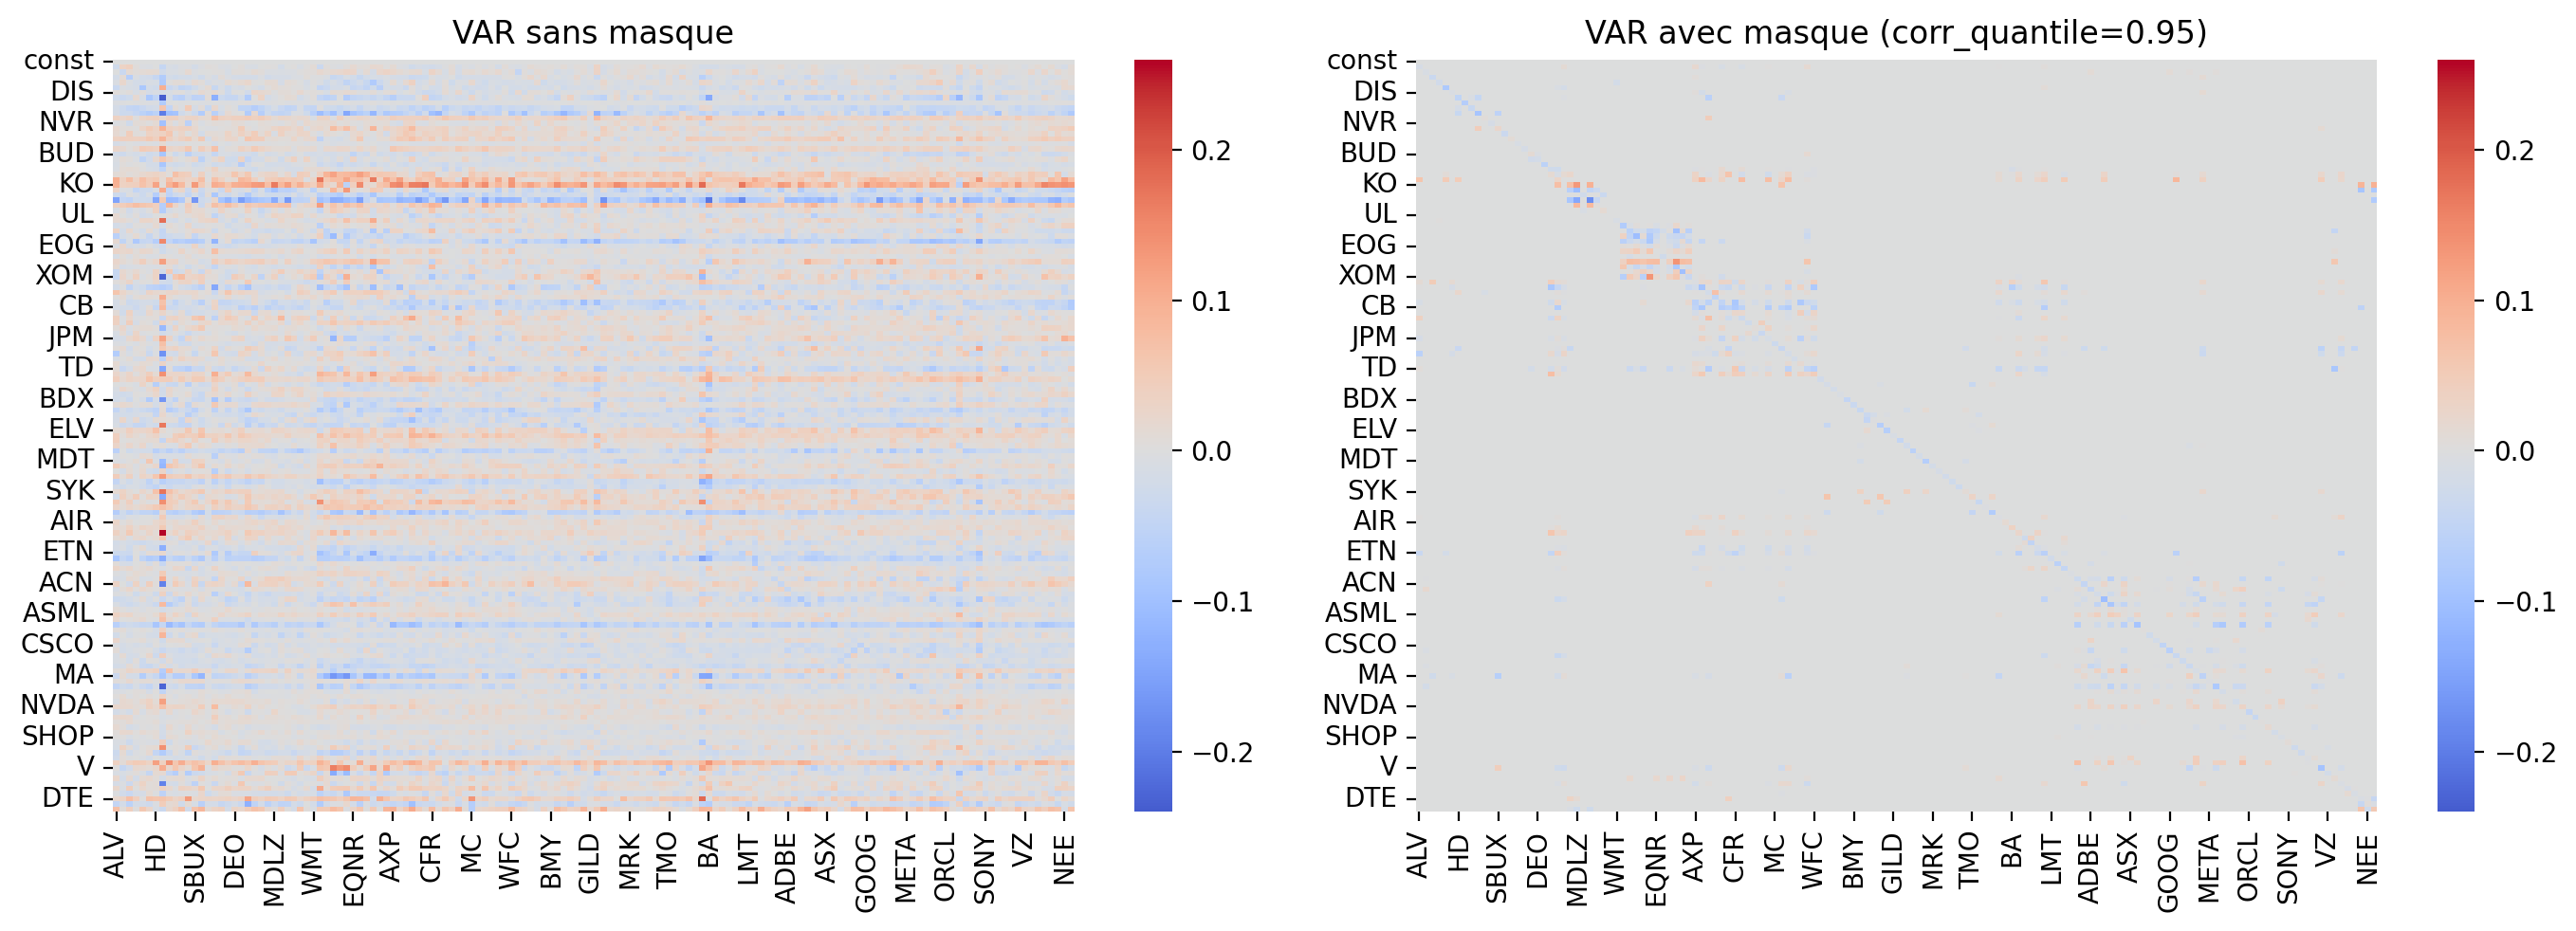

In [9]:
# Comparaison visuelle : sans masque vs avec masque
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vmin = min(matrix_no_mask.values.min(), matrix_masked.values.min())
vmax = max(matrix_no_mask.values.max(), matrix_masked.values.max())

sns.heatmap(matrix_no_mask, annot=False, cmap='coolwarm', center=0, vmin=vmin, vmax=vmax, ax=axes[0])
axes[0].set_title("VAR sans masque")

sns.heatmap(matrix_masked, annot=False, cmap='coolwarm', center=0, vmin=vmin, vmax=vmax, ax=axes[1])
axes[1].set_title("VAR avec masque (corr_quantile=0.95)")

plt.tight_layout()
plt.show()

## Rolling contagion

In [40]:
from importlib import reload
import functions; reload(functions)
from functions import *

data = load_data(['stock'], log_returns=True, sort_by_sector=True)
res = rolling_contagion(data, corr_quantile=0.1, asset_type="stock", interval_size=100)

### Etude récurrence des coéfficients

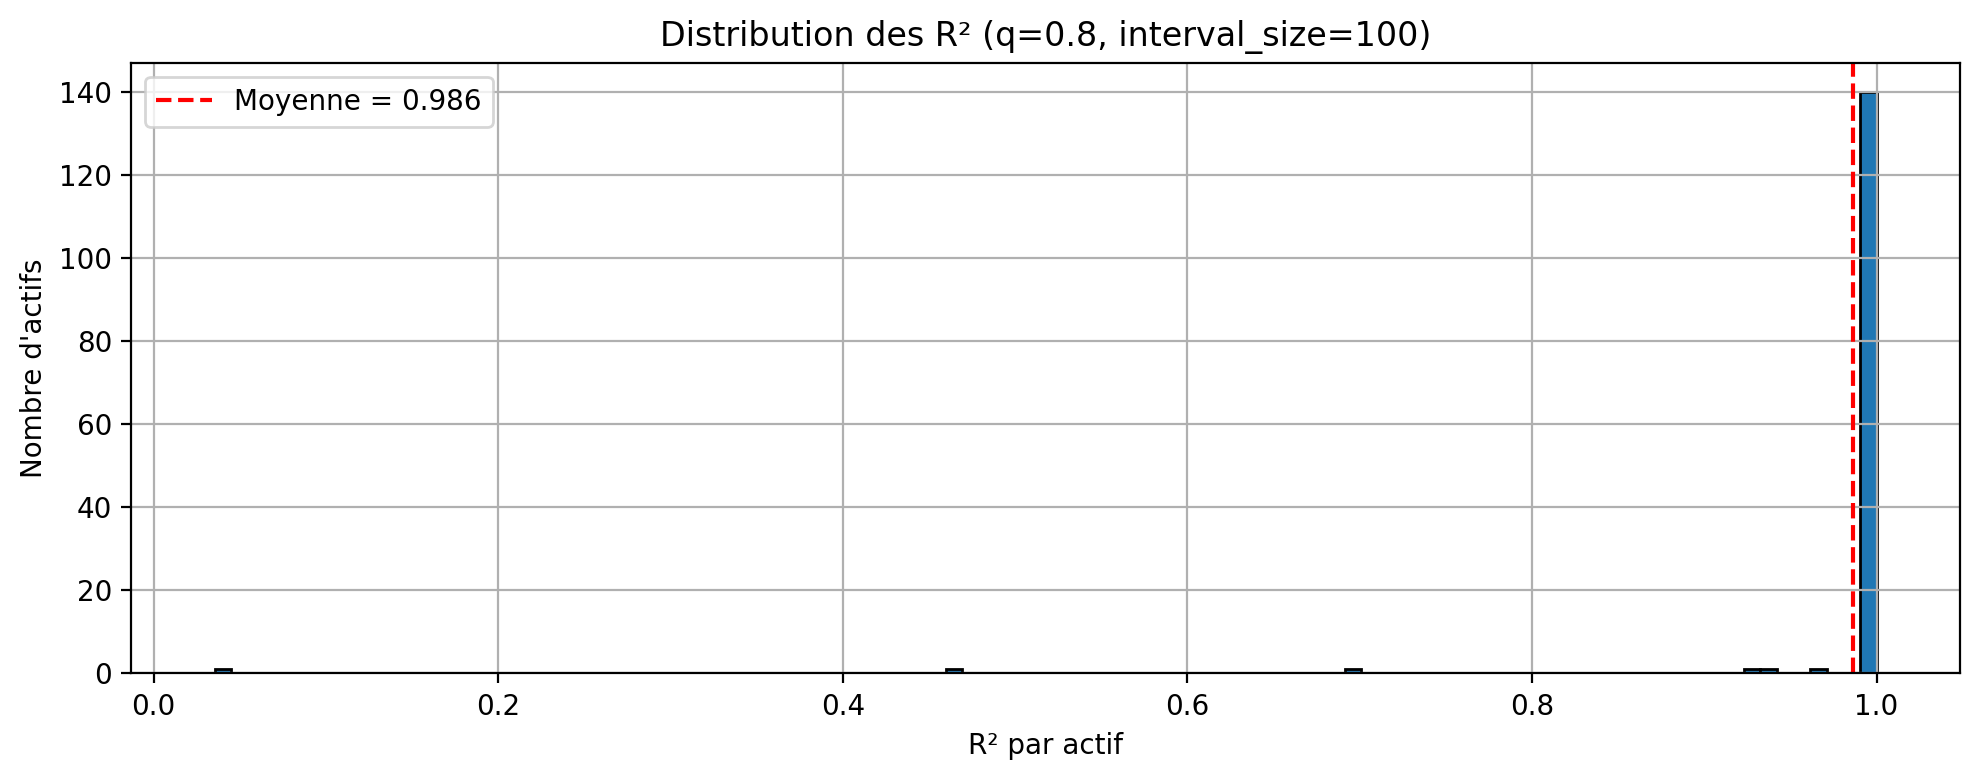

10 actifs les plus faibles :
  IDEX: R²=0.0354, 1 regresseurs
  PDD: R²=0.4612, 2 regresseurs
  NFLX: R²=0.6957, 4 regresseurs
  BABA: R²=0.9281, 2 regresseurs
  GILD: R²=0.9337, 2 regresseurs
  LLY: R²=0.9654, 5 regresseurs
  BKNG: R²=1.0000, 59 regresseurs
  ALV: R²=1.0000, 75 regresseurs
  LOW: R²=1.0000, 52 regresseurs
  MCD: R²=1.0000, 55 regresseurs


In [11]:
# Distribution des R² par actif (q=0.8)
size = 100
res = rolling_contagion(data, corr_quantile=0.1, asset_type="stock", interval_size=size)

fig, ax = plt.subplots(figsize=(10, 4))
res['r2_per_asset'].hist(bins=100, ax=ax, edgecolor='black')
ax.axvline(res['r2_total'], color='red', linestyle='--', label=f"Moyenne = {res['r2_total']:.3f}")
ax.set_xlabel("R² par actif")
ax.set_ylabel("Nombre d'actifs")
ax.set_title(f"Distribution des R² (q=0.8, interval_size={size})")
ax.legend()
plt.tight_layout()
plt.show()

# Les pires actifs et leur nombre de regresseurs
corr = correlation(data.values, 0)
mask = corr_threshold(corr, 0.7)
n_reg = pd.Series((mask != 0).sum(axis=0), index=data.columns)
r2_sorted = res['r2_per_asset'].sort_values()

print("10 actifs les plus faibles :")
for asset in r2_sorted.head(10).index:
    print(f"  {asset}: R²={res['r2_per_asset'][asset]:.4f}, {n_reg[asset]} regresseurs")

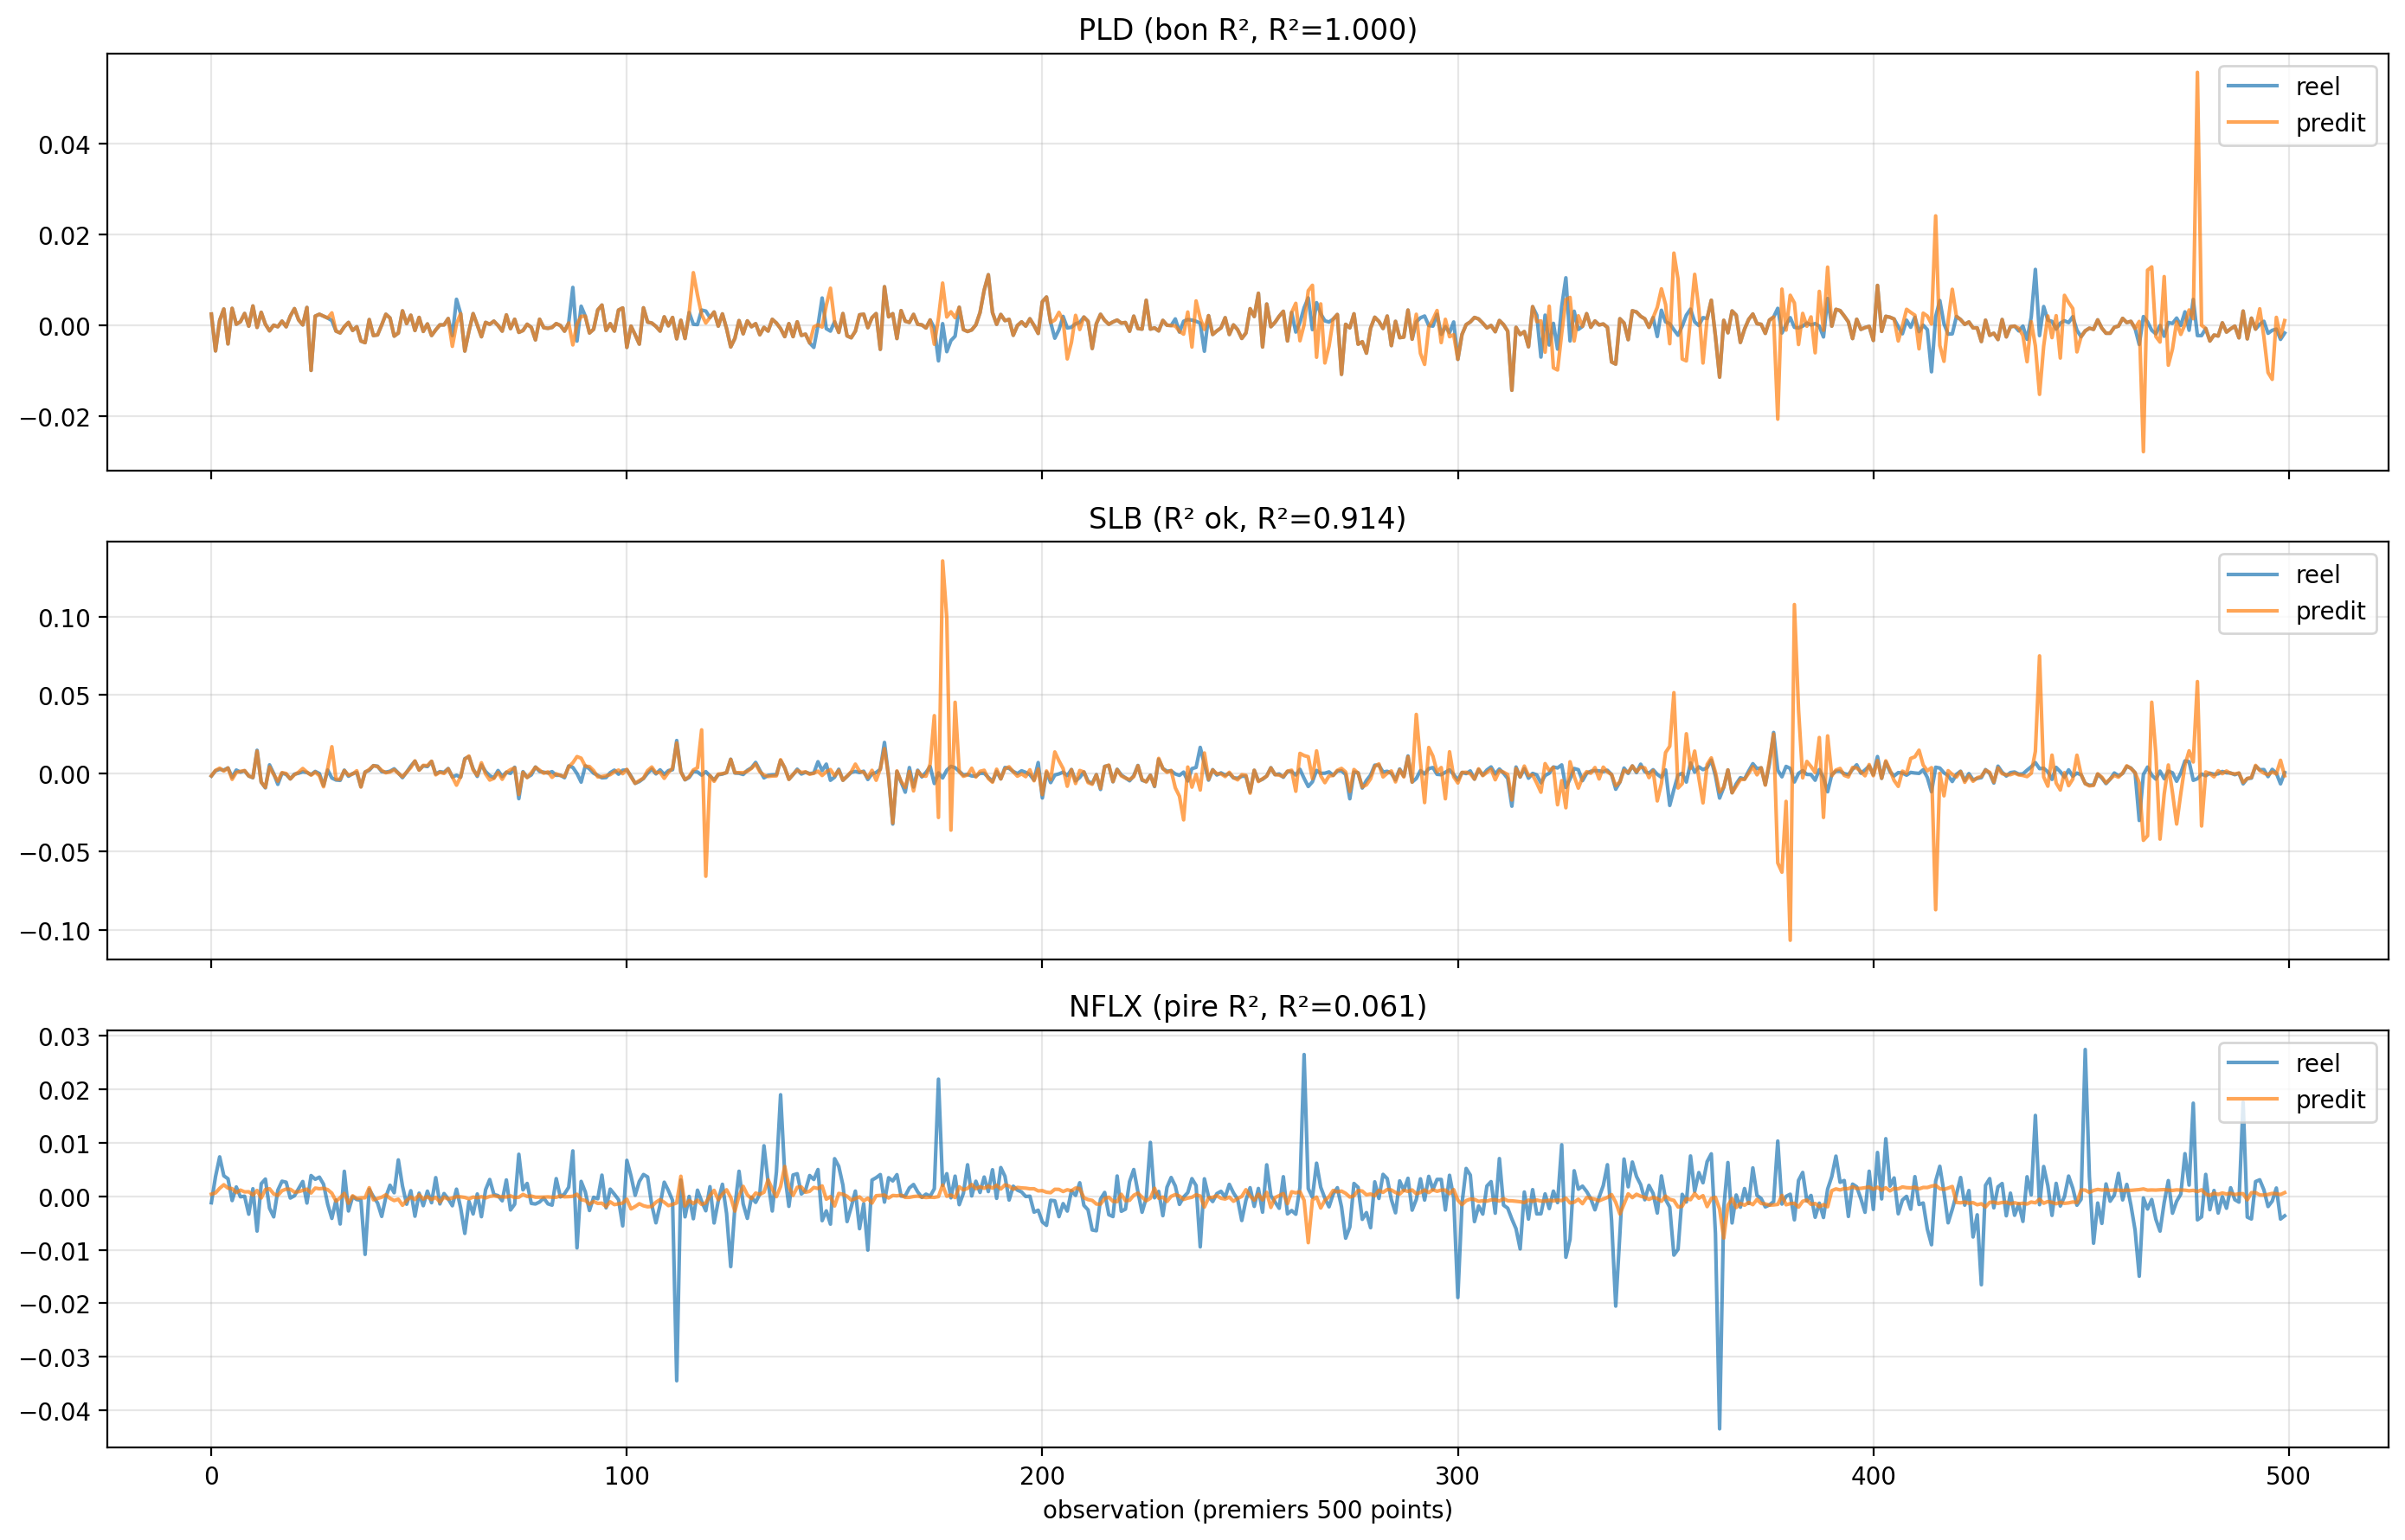

In [41]:
# Verification du fit : reel vs predit pour quelques actifs (lag=1, corr_q=0.8, n=30)
from importlib import reload
import functions; reload(functions)
from functions import *

lag = 1
interval_size = 30
window = interval_size + lag

res = rolling_contagion(data, corr_quantile=0.8, asset_type="stock",
                        interval_size=interval_size, lag=lag)

assets = data.columns.tolist()
raw = data.values

y_hat_all, y_true_all = [], []
for i, matrix in enumerate(res["matrices"]):
    start = i * window
    end = start + window
    X_lag = raw[start:end - lag]
    y_true = raw[start + lag:end]
    coef = matrix.loc[assets].values
    const = matrix.loc["const"].values
    y_hat_all.append(X_lag @ coef + const)
    y_true_all.append(y_true)
y_hat_all = np.concatenate(y_hat_all, axis=0)
y_true_all = np.concatenate(y_true_all, axis=0)

r2_sorted = res["r2_per_asset"].sort_values()
pick = [r2_sorted.index[-1], r2_sorted.index[len(r2_sorted) // 2], r2_sorted.index[0]]
labels = ["bon R²", "R² ok", "pire R²"]

n_show = 500
fig, axes = plt.subplots(len(pick), 1, figsize=(14, 3 * len(pick)), sharex=True)
for ax, asset, lab in zip(axes, pick, labels):
    j = assets.index(asset)
    ax.plot(y_true_all[:n_show, j], label="reel", alpha=0.7)
    ax.plot(y_hat_all[:n_show, j], label="predit", alpha=0.7)
    ax.set_title(f"{asset} ({lab}, R²={res['r2_per_asset'][asset]:.3f})")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel(f"observation (premiers {n_show} points)")
plt.tight_layout()
plt.show()


### Coefficients recurrents ?

Rolling contagion: 100%|██████████| 140/140 [00:49<00:00,  2.81it/s]


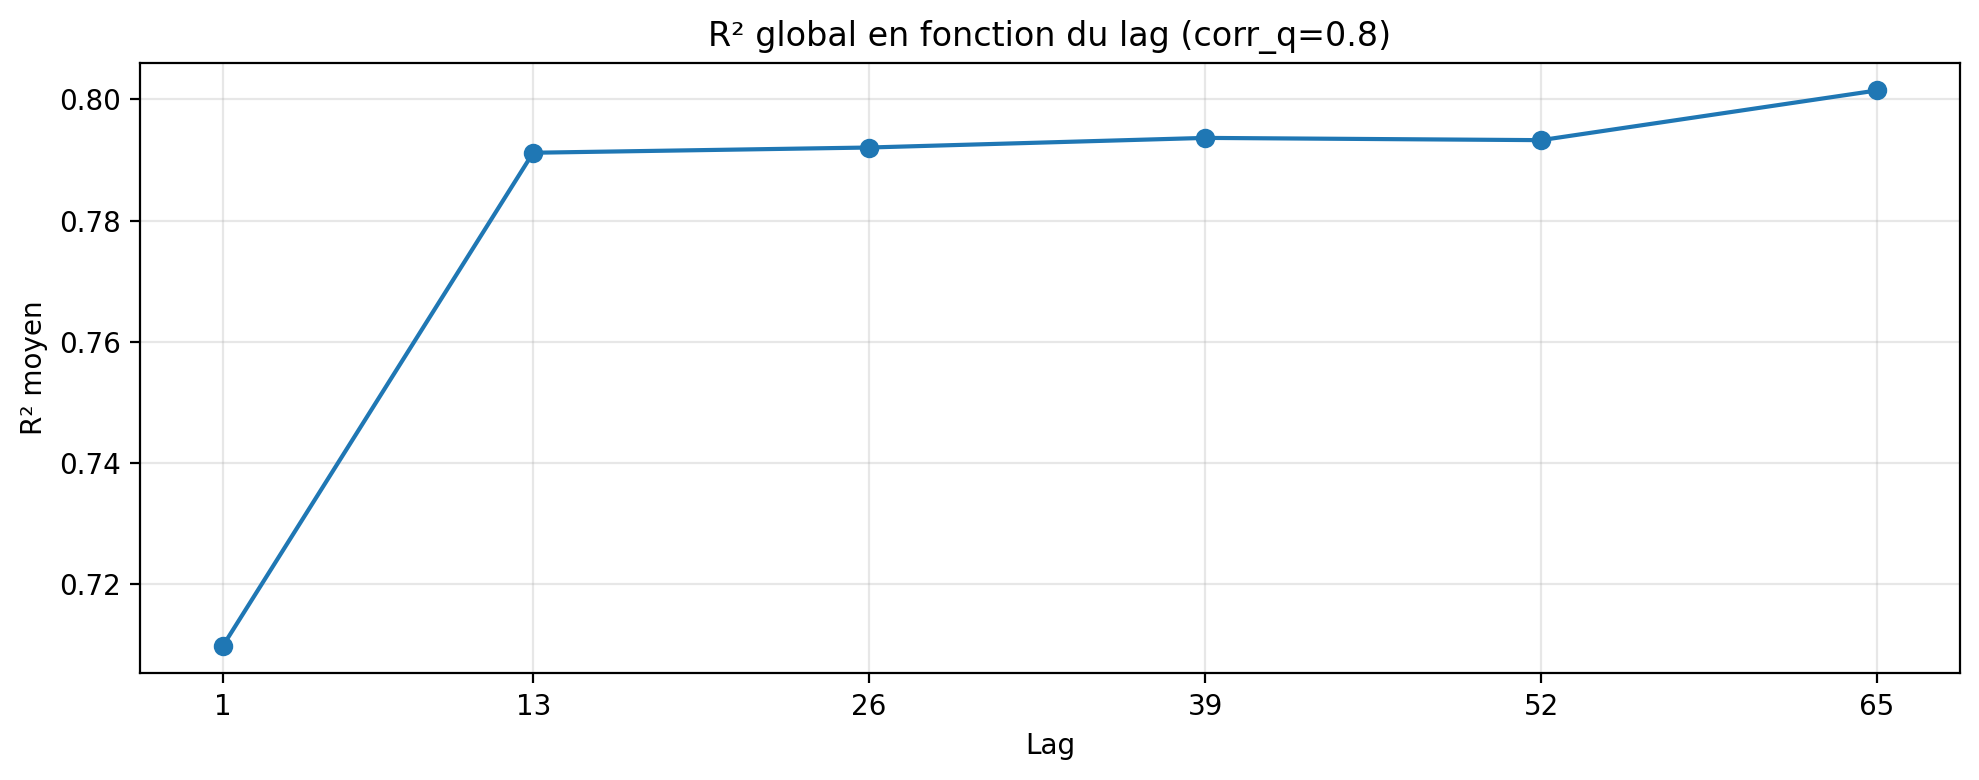

In [12]:
from importlib import reload
import functions; reload(functions)
from functions import *

lags = [1,13] + [13 * k for k in range(2, 6)]
results = {}
for lag in lags:
    act = activation_frequency(data, corr_quantile=0.8, asset_type="stock",
                               interval_size=30, binarization_quantile=0.5,
                               lag=lag, plot=False)

    results[lag] = {
        "freq": act["freq"],
        "r2_total": act["rolling"]["r2_total"],
        "r2_per_asset": act["rolling"]["r2_per_asset"],
    }

n = len(lags)
ncols = (n + 1) // 2

# R² en fonction du lag
r2_totals = [results[l]["r2_total"] for l in lags]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lags, r2_totals, "o-")
ax.set_xlabel("Lag")
ax.set_ylabel("R² moyen")
ax.set_title("R² global en fonction du lag (corr_q=0.8)")
ax.set_xticks(lags)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Fréquence d'apparition des coefficients

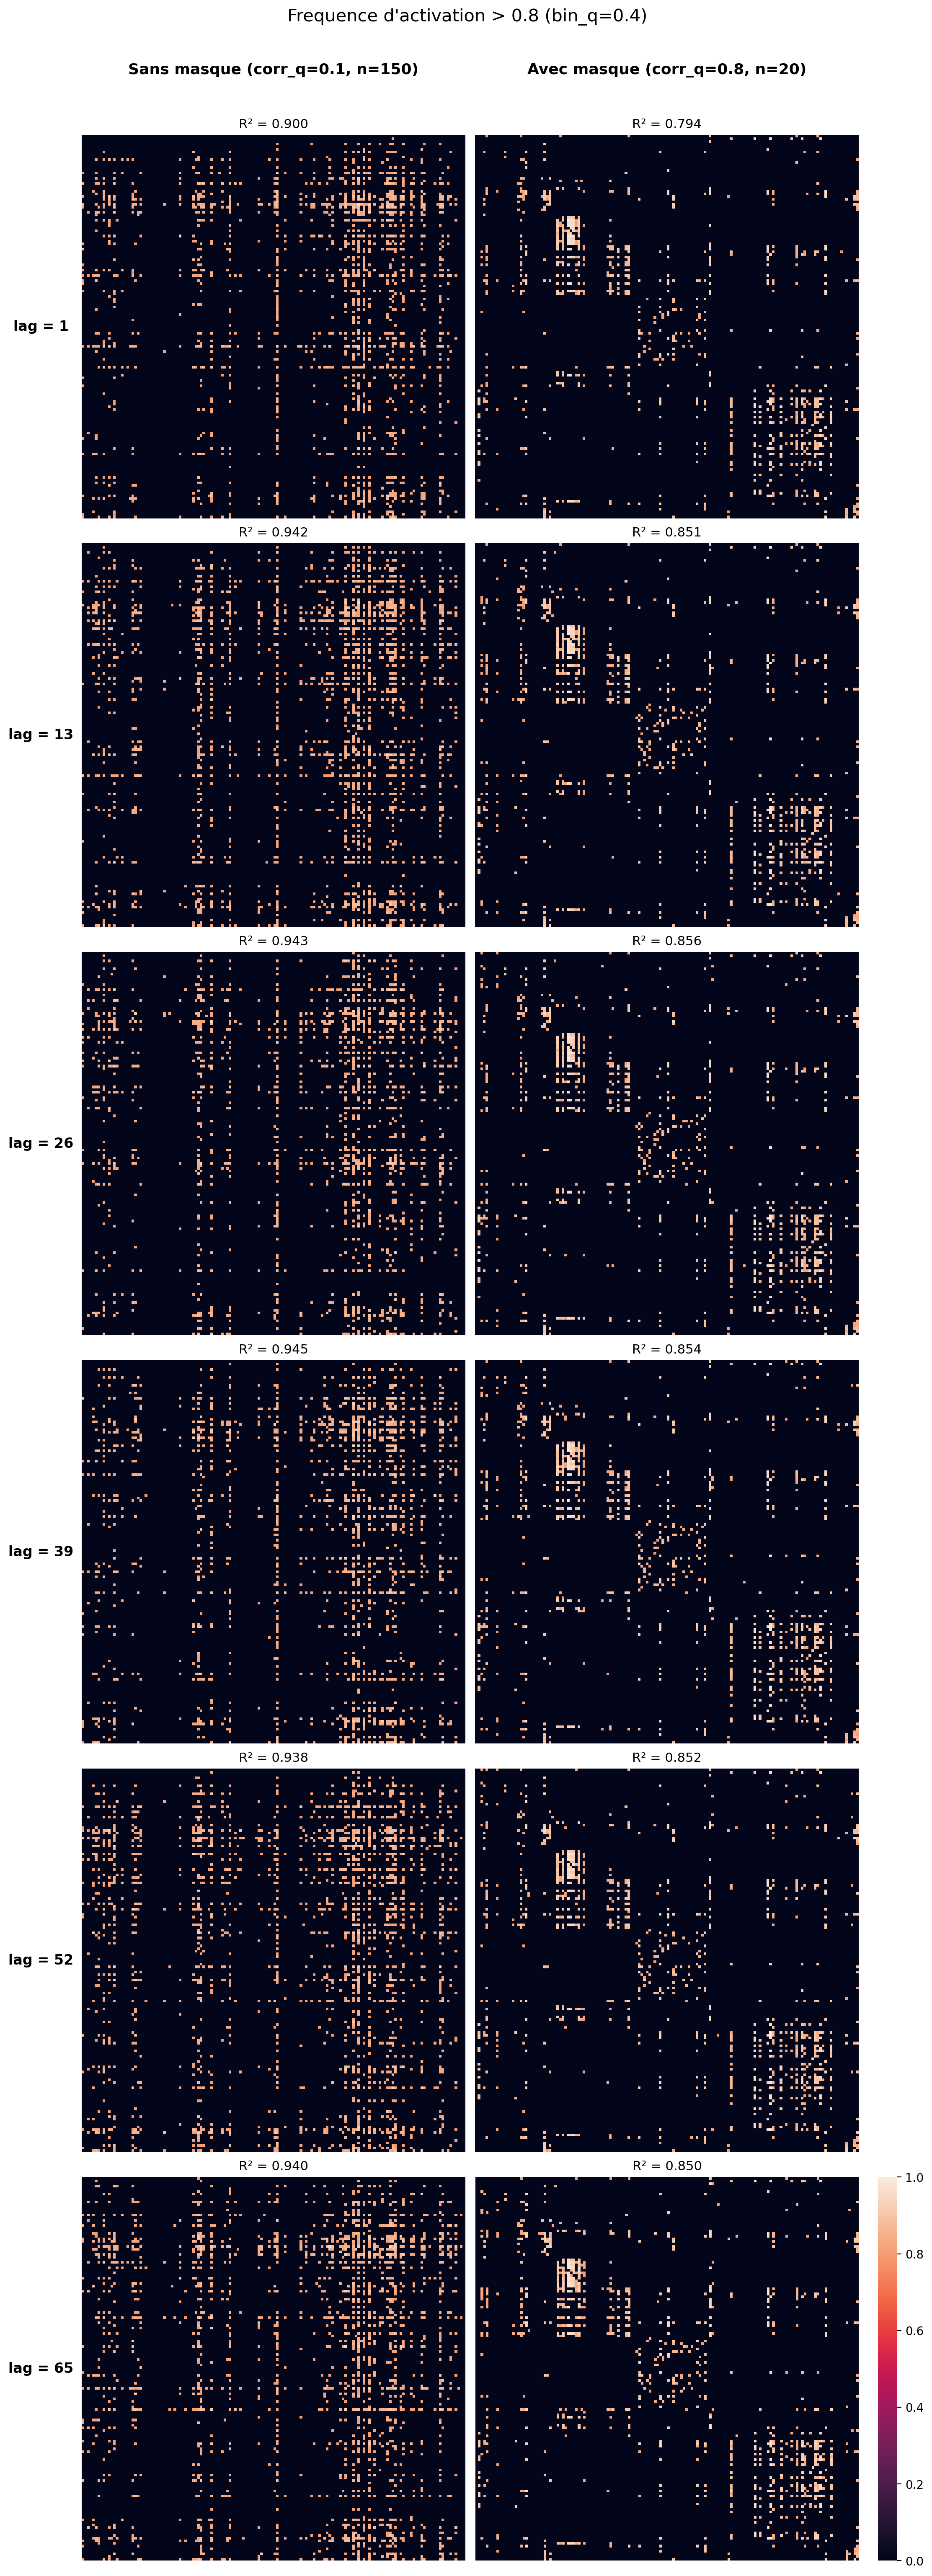

In [23]:
from importlib import reload
import functions; reload(functions)
from functions import *

lags = [1] + [13 * k for k in range(1, 6)]
results = {}
for lag in lags:
    act_sans = activation_frequency(data, corr_quantile=0.1, asset_type="stock",
                                    interval_size=150, binarization_quantile=0.4,
                                    lag=lag, plot=False)
    act_avec = activation_frequency(data, corr_quantile=0.8, asset_type="stock",
                                    interval_size=20, binarization_quantile=0.4,
                                    lag=lag, plot=False)
    results[lag] = {
        "sans": act_sans["freq"],
        "avec": act_avec["freq"],
        "r2_sans": act_sans["rolling"]["r2_total"],
        "r2_avec": act_avec["rolling"]["r2_total"],
    }

n = len(lags)
fig, axes = plt.subplots(n, 2, figsize=(11, 5 * n), constrained_layout=True)
if n == 1:
    axes = axes[np.newaxis, :]

col_labels = ["Sans masque (corr_q=0.1, n=150)", "Avec masque (corr_q=0.8, n=20)"]
for j, label in enumerate(col_labels):
    axes[0, j].annotate(label, xy=(0.5, 1.15), xycoords="axes fraction",
                        ha="center", va="bottom", fontsize=13, fontweight="bold")

last_im = None
for i, lag in enumerate(lags):
    r = results[lag]
    for j, (key, r2_key) in enumerate([("sans", "r2_sans"), ("avec", "r2_avec")]):
        show_cbar = (i == n - 1 and j == 1)
        sns.heatmap(np.where(r[key] > 0.8, r[key], 0),
                    vmin=0, vmax=1, ax=axes[i, j], cbar=show_cbar, square=True)
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
        axes[i, j].set_title(f"R² = {r[r2_key]:.3f}", fontsize=11)

    axes[i, 0].set_ylabel(f"lag = {lag}", fontsize=12, fontweight="bold",
                          rotation=0, labelpad=35, va="center")

fig.suptitle("Frequence d'activation > 0.8 (bin_q=0.4)", fontsize=15, y=1.02)
plt.show()


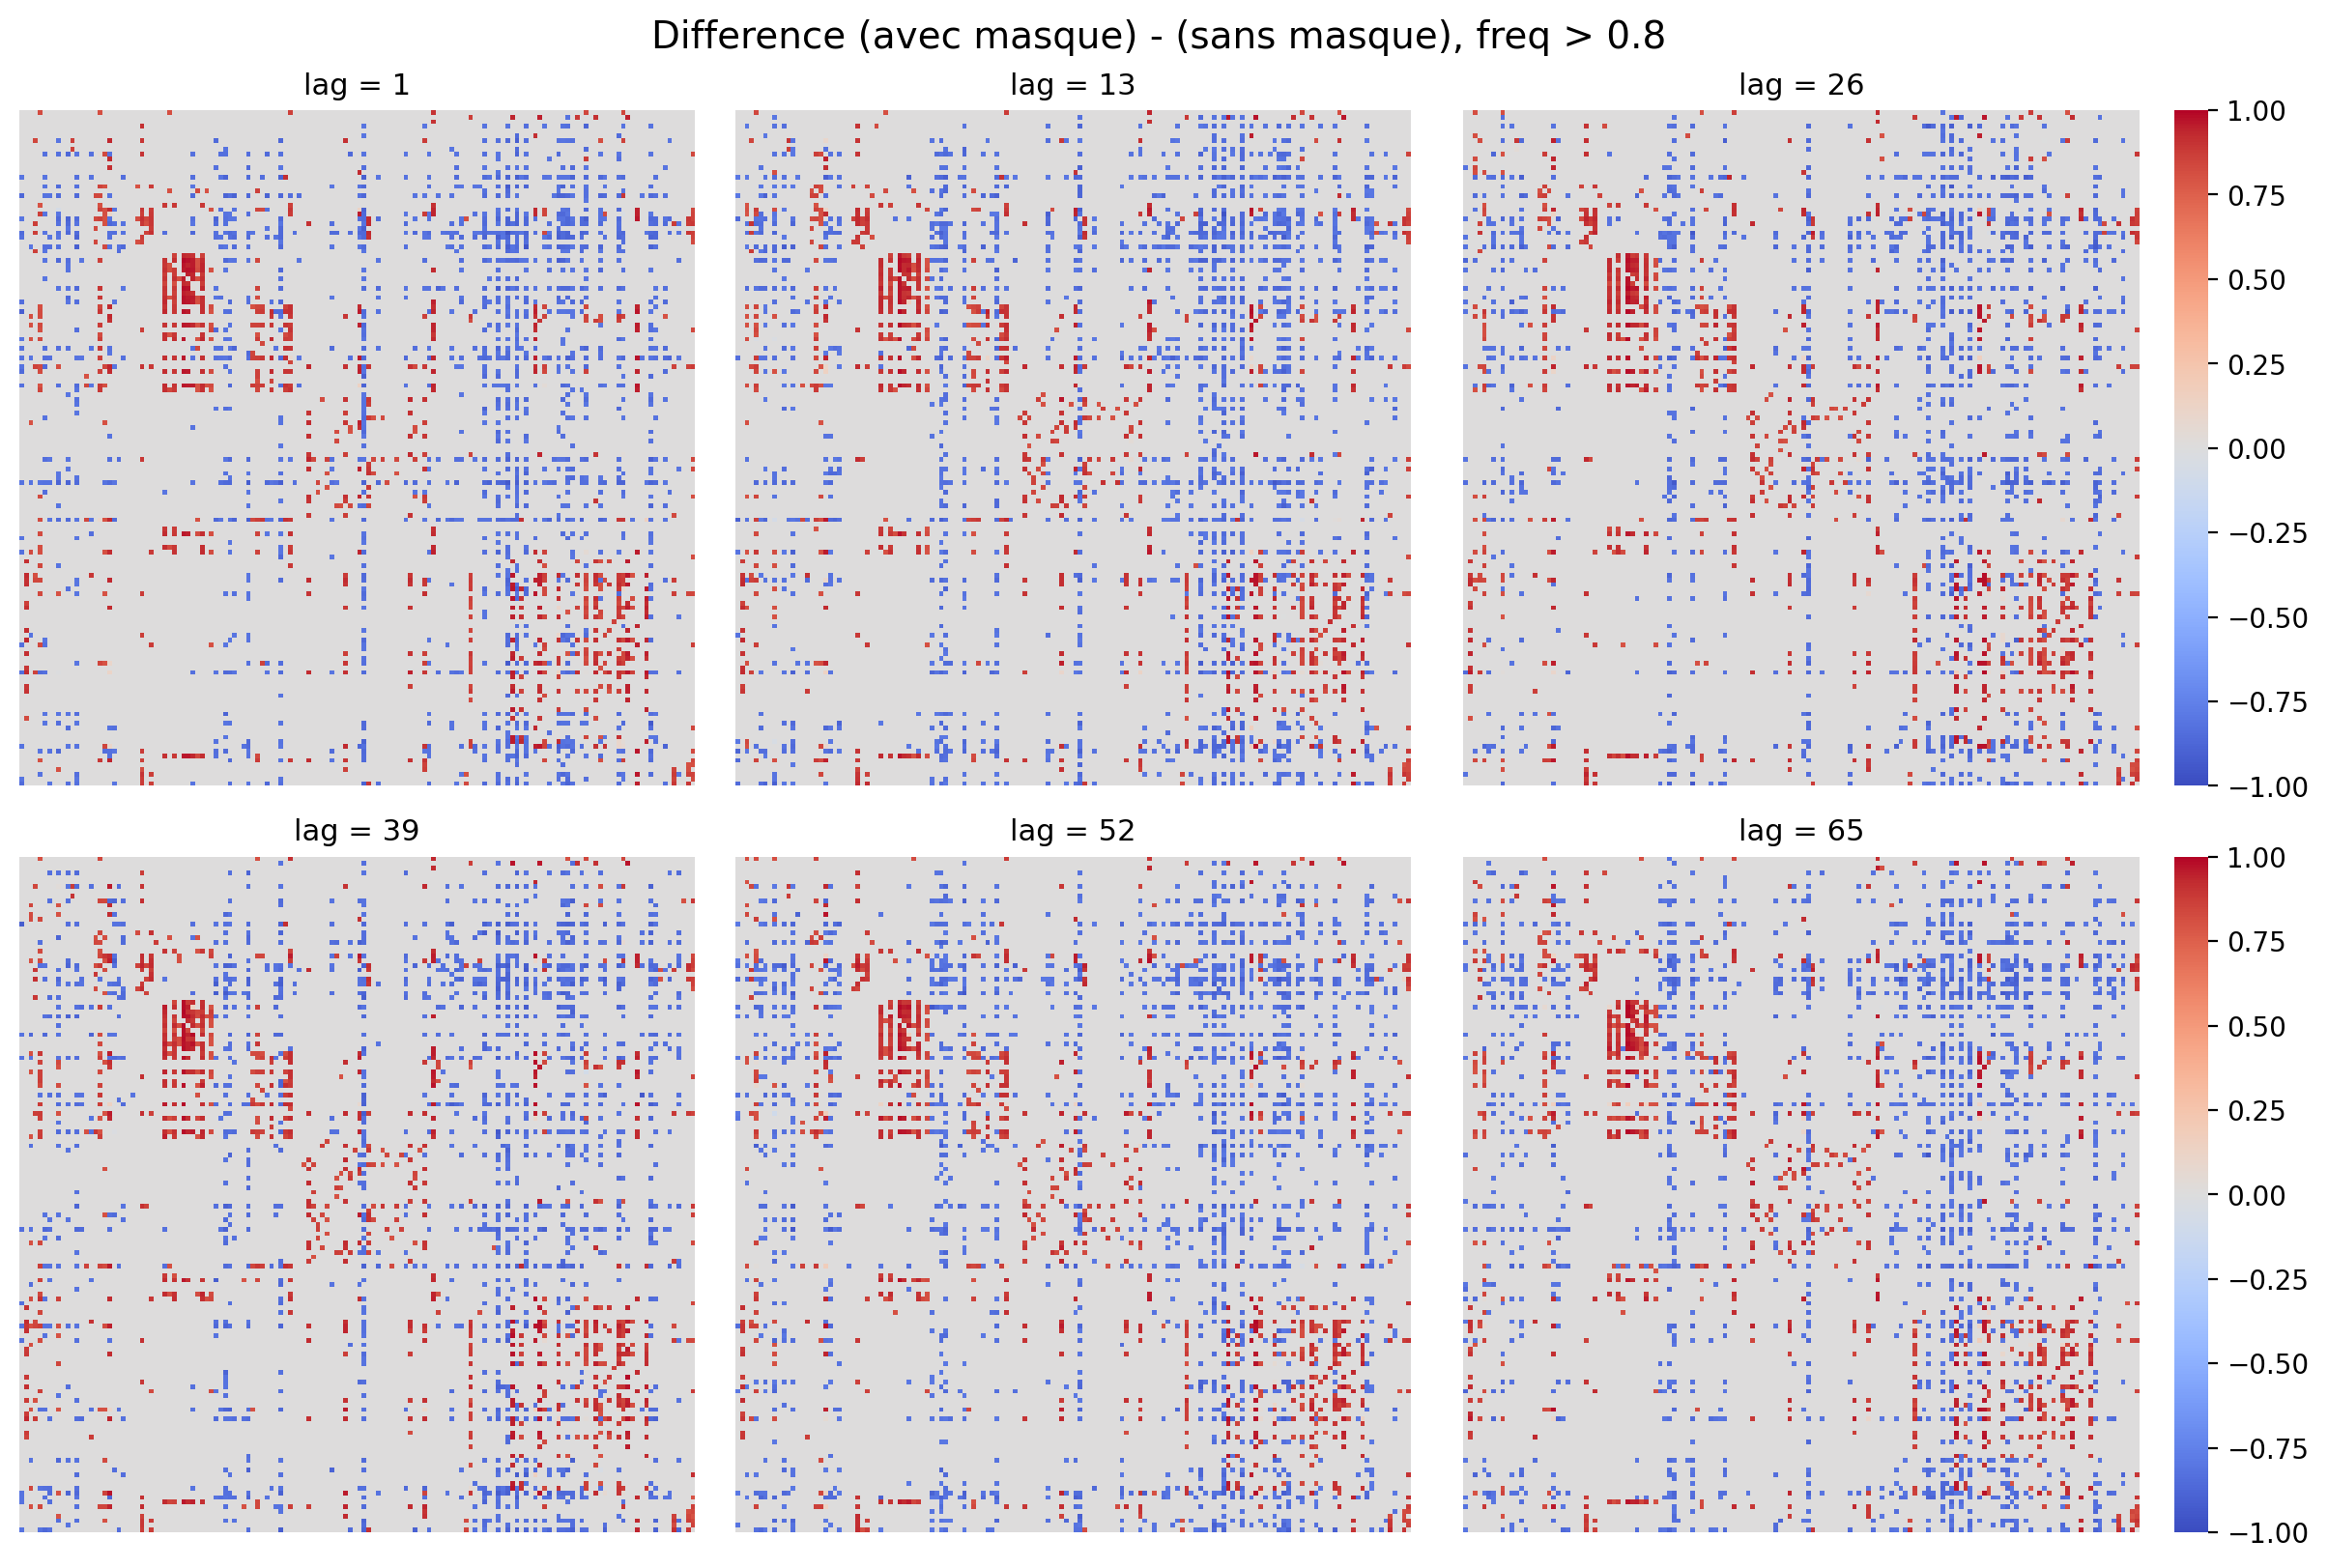

In [29]:
# Difference avec - sans masque (frequence d'activation > 0.8)
n = len(lags)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows),
                         constrained_layout=True)
axes = np.atleast_2d(axes)

diffs = []
for lag in lags:
    r = results[lag]
    sans = np.where(r["sans"] > 0.8, r["sans"], 0)
    avec = np.where(r["avec"] > 0.8, r["avec"], 0)
    diffs.append(avec - sans)

vmax = max(np.abs(d).max() for d in diffs)

for k, (lag, d) in enumerate(zip(lags, diffs)):
    ax = axes[k // ncols, k % ncols]
    show_cbar = (k % ncols == ncols - 1)
    sns.heatmap(d, cmap="coolwarm", center=0, vmin=-vmax, vmax=vmax,
                ax=ax, cbar=show_cbar, square=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"lag = {lag}", fontsize=11)

for k in range(n, nrows * ncols):
    axes[k // ncols, k % ncols].axis("off")

fig.suptitle("Difference (avec masque) - (sans masque), freq > 0.8", fontsize=14)
plt.show()

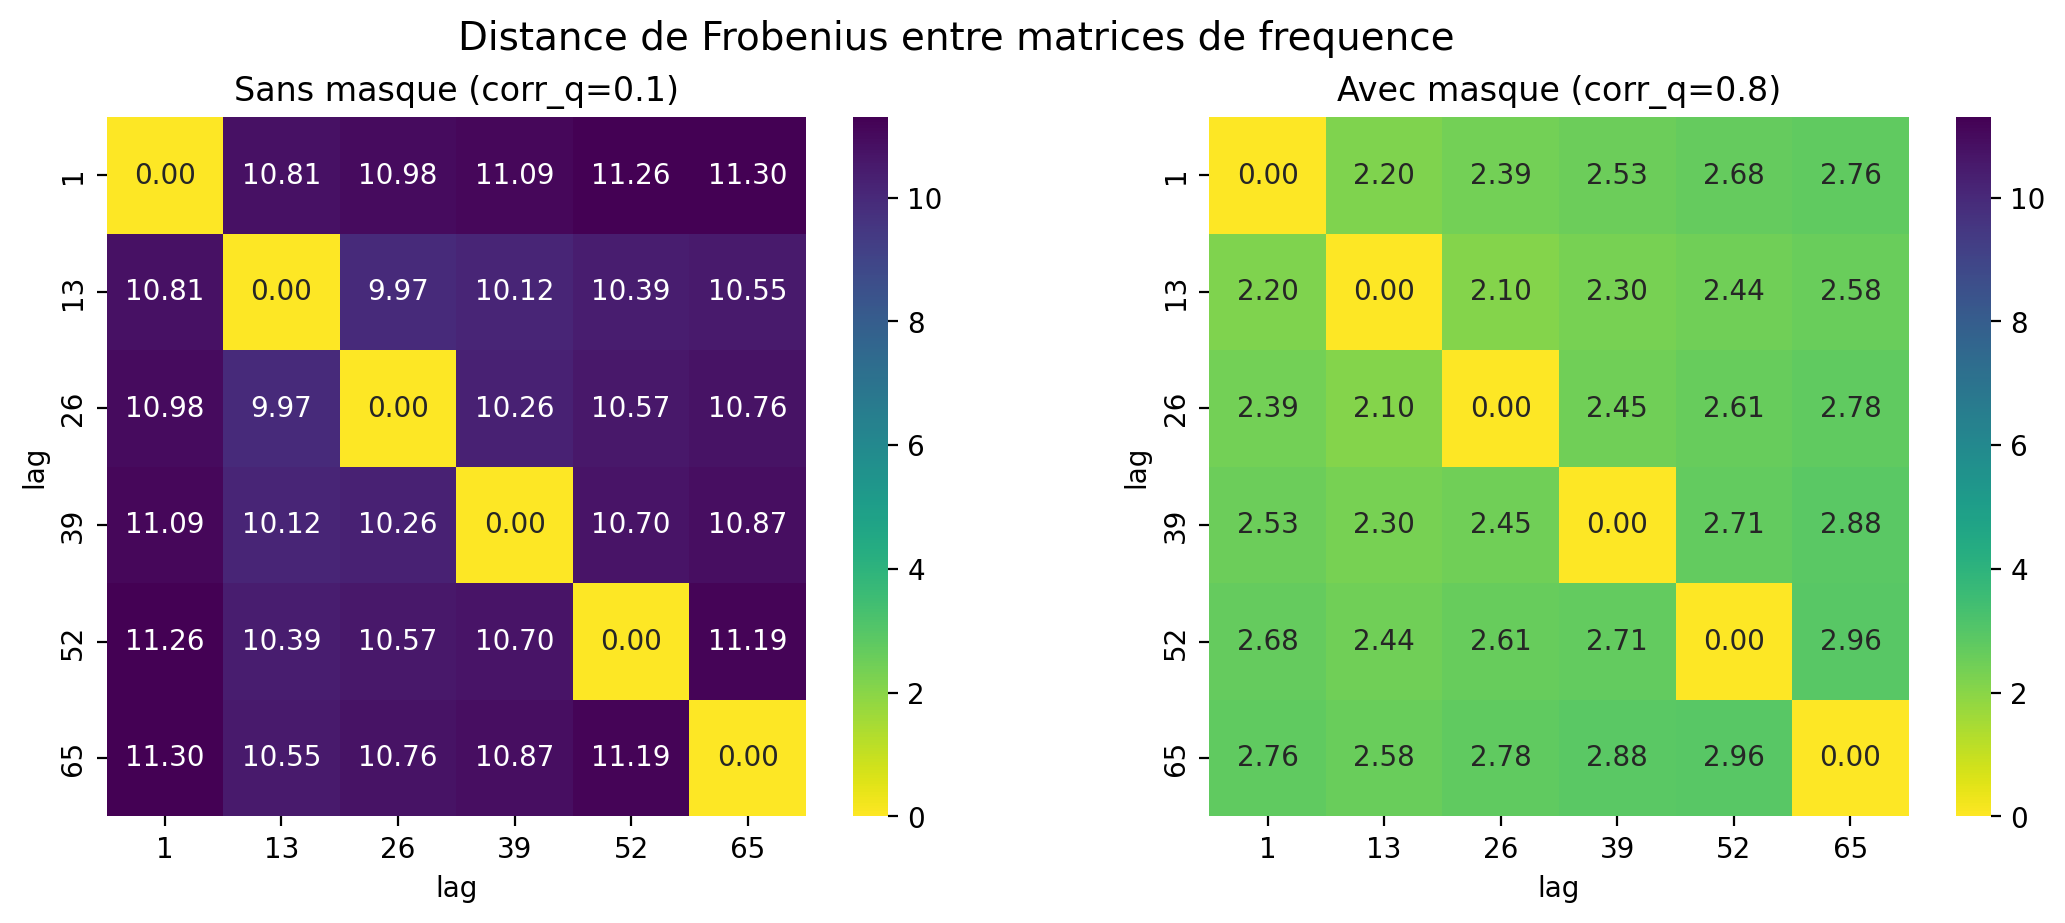

In [30]:
# Distance de Frobenius ||A - B||_F entre matrices de frequence, par masque
def _similarity_grid(items, metric):
    n = len(items)
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = metric(items[i], items[j])
    return M

lag_labels = [str(l) for l in lags]
keys = [("sans", "Sans masque (corr_q=0.1)"),
        ("avec", "Avec masque (corr_q=0.8)")]

dists = []
for key, _ in keys:
    freqs_raw = [np.asarray(results[l][key]) for l in lags]
    dists.append(_similarity_grid(freqs_raw, lambda a, b: np.linalg.norm(a - b)))

vmax = max(d.max() for d in dists)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, (_, title), d in zip(axes, keys, dists):
    sns.heatmap(d, annot=True, fmt=".2f", vmin=0, vmax=vmax, cmap="viridis_r",
                xticklabels=lag_labels, yticklabels=lag_labels, ax=ax, square=True)
    ax.set_title(title)
    ax.set_xlabel("lag"); ax.set_ylabel("lag")

fig.suptitle("Distance de Frobenius entre matrices de frequence", fontsize=14)
plt.show()


(à priori matrices proches mais pas identiques à chaque fois)

### Étude des médianes de contagion

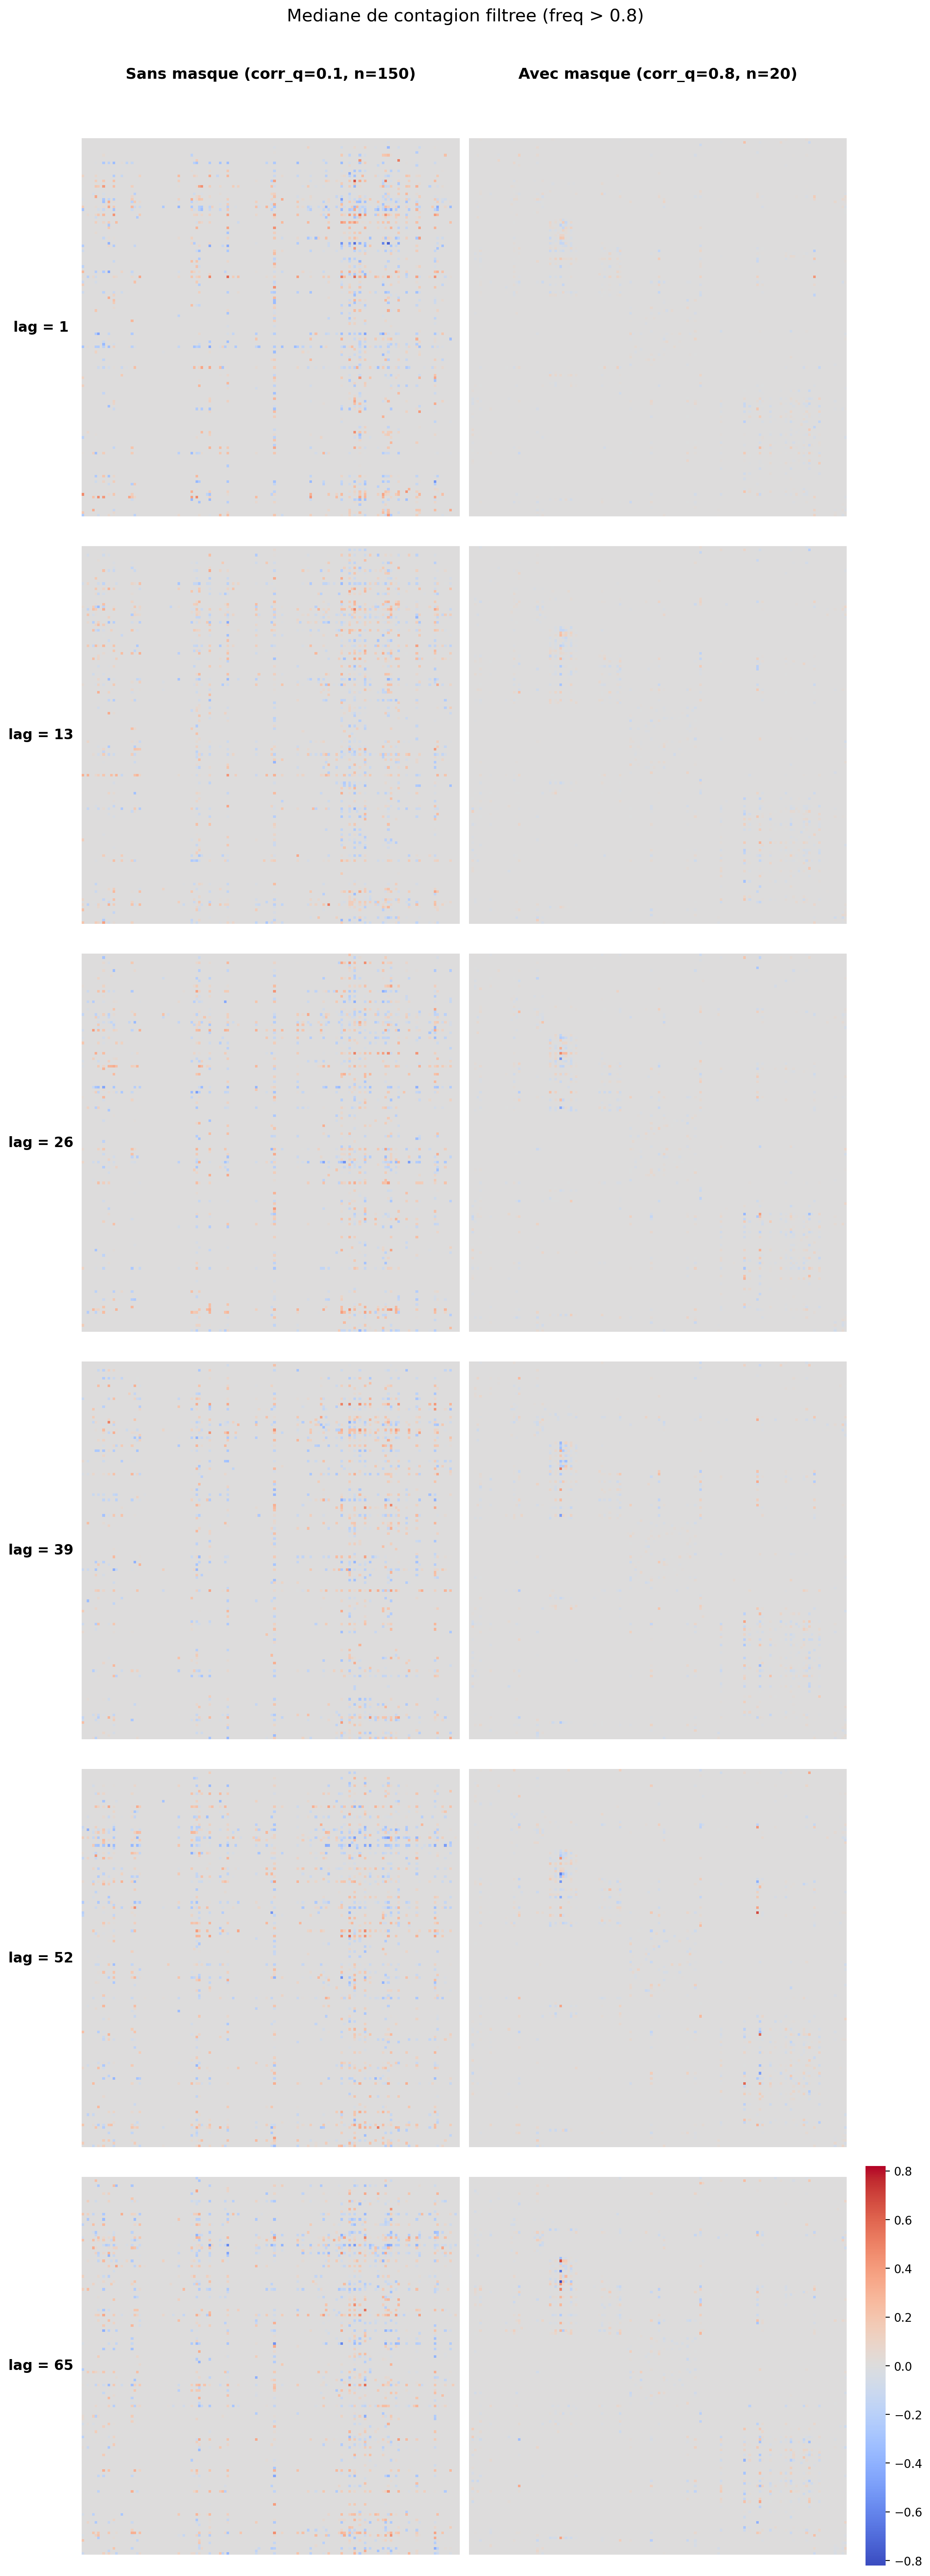

In [38]:
# Matrices medianes filtrees (freq > 0.8), cote a cote par lag
from importlib import reload
import functions; reload(functions)
from functions import *

def _median_from_act(act_result, freq_threshold=0.8):
    assets = act_result["rolling"]["matrices"][0].columns.tolist()
    mat_arr = np.array([m.loc[assets].values for m in act_result["rolling"]["matrices"]])
    for m in mat_arr:
        np.fill_diagonal(m, 0)
    median_coeff = np.median(mat_arr, axis=0)
    mask_freq = np.asarray(act_result["freq"]) > freq_threshold
    return np.where(mask_freq, median_coeff, 0)

medians = {"sans": [], "avec": []}
for lag in lags:
    act_sans = activation_frequency(data, corr_quantile=0.1, asset_type="stock",
                                    interval_size=150, binarization_quantile=0.4,
                                    lag=lag, plot=False)
    act_avec = activation_frequency(data, corr_quantile=0.8, asset_type="stock",
                                    interval_size=20, binarization_quantile=0.4,
                                    lag=lag, plot=False)
    medians["sans"].append(_median_from_act(act_sans))
    medians["avec"].append(_median_from_act(act_avec))

vmax = max(max(np.abs(m).max() for m in medians["sans"]),
           max(np.abs(m).max() for m in medians["avec"]))

n = len(lags)
fig, axes = plt.subplots(n, 2, figsize=(11, 5 * n), constrained_layout=True)
if n == 1:
    axes = axes[np.newaxis, :]

col_labels = ["Sans masque (corr_q=0.1, n=150)", "Avec masque (corr_q=0.8, n=20)"]
for j, label in enumerate(col_labels):
    axes[0, j].annotate(label, xy=(0.5, 1.15), xycoords="axes fraction",
                        ha="center", va="bottom", fontsize=13, fontweight="bold")

for i, lag in enumerate(lags):
    for j, key in enumerate(["sans", "avec"]):
        show_cbar = (i == n - 1 and j == 1)
        sns.heatmap(medians[key][i], cmap="coolwarm", center=0,
                    vmin=-vmax, vmax=vmax, ax=axes[i, j],
                    cbar=show_cbar, square=True)
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
    axes[i, 0].set_ylabel(f"lag = {lag}", fontsize=12, fontweight="bold",
                          rotation=0, labelpad=35, va="center")

fig.suptitle("Mediane de contagion filtree (freq > 0.8)", fontsize=15, y=1.02)
plt.show()


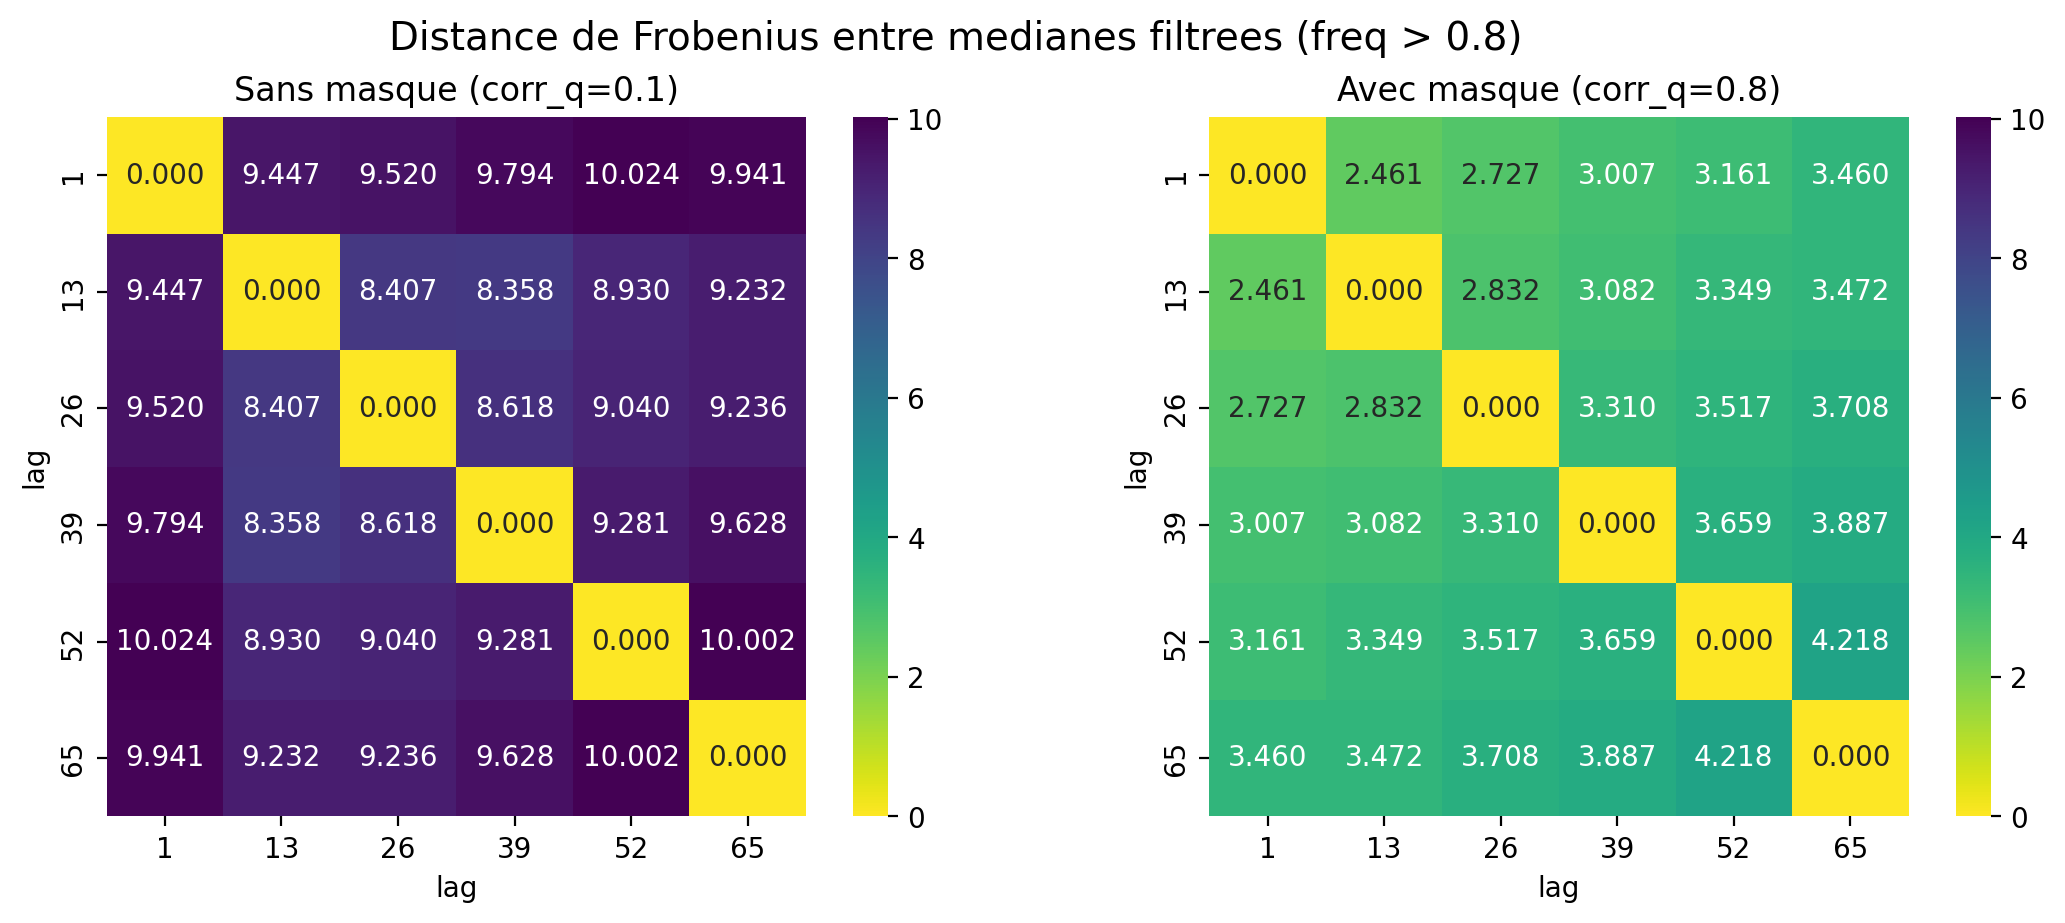

In [35]:
# Distance de Frobenius entre matrices medianes filtrees (freq > 0.8), par masque
from importlib import reload
import functions; reload(functions)
from functions import *

def _median_from_act(act_result, freq_threshold=0.8):
    assets = act_result["rolling"]["matrices"][0].columns.tolist()
    mat_arr = np.array([m.loc[assets].values for m in act_result["rolling"]["matrices"]])
    for m in mat_arr:
        np.fill_diagonal(m, 0)
    median_coeff = np.median(mat_arr, axis=0)
    mask_freq = np.asarray(act_result["freq"]) > freq_threshold
    return np.where(mask_freq, median_coeff, 0)

medians = {"sans": [], "avec": []}
for lag in lags:
    act_sans = activation_frequency(data, corr_quantile=0.1, asset_type="stock",
                                    interval_size=150, binarization_quantile=0.4,
                                    lag=lag, plot=False)
    act_avec = activation_frequency(data, corr_quantile=0.8, asset_type="stock",
                                    interval_size=20, binarization_quantile=0.4,
                                    lag=lag, plot=False)
    medians["sans"].append(_median_from_act(act_sans))
    medians["avec"].append(_median_from_act(act_avec))

def _similarity_grid(items, metric):
    n = len(items)
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = metric(items[i], items[j])
    return M

lag_labels = [str(l) for l in lags]
keys = [("sans", "Sans masque (corr_q=0.1)"),
        ("avec", "Avec masque (corr_q=0.8)")]

dists = [_similarity_grid(medians[k], lambda a, b: np.linalg.norm(a - b)) for k, _ in keys]
vmax = max(d.max() for d in dists)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, (_, title), d in zip(axes, keys, dists):
    sns.heatmap(d, annot=True, fmt=".3f", vmin=0, vmax=vmax, cmap="viridis_r",
                xticklabels=lag_labels, yticklabels=lag_labels, ax=ax, square=True)
    ax.set_title(title)
    ax.set_xlabel("lag"); ax.set_ylabel("lag")

fig.suptitle("Distance de Frobenius entre medianes filtrees (freq > 0.8)", fontsize=14)
plt.show()


### Graphes (avec la frequence)

In [ ]:
# Graphe dirige des liens recurrents (freq > 0.8, avec masque, lag=1) via ForceAtlas2
import networkx as nx

freq_matrix = np.asarray(results[1]["avec"])
assets = data.columns.tolist()

adj = np.where(freq_matrix > 0.8, freq_matrix, 0)
np.fill_diagonal(adj, 0)
G = nx.from_numpy_array(adj, create_using=nx.DiGraph)
G = nx.relabel_nodes(G, {i: assets[i] for i in range(len(assets))})
G.remove_nodes_from(list(nx.isolates(G)))

cat = pd.read_excel("data/stock_category.xlsx")
sector_by_asset = cat.set_index("Stocks")["Sectors"].to_dict()
sectors = sorted({sector_by_asset.get(n, "autre") for n in G.nodes()})
palette = sns.color_palette("tab20", n_colors=len(sectors))
color_by_sector = dict(zip(sectors, palette))
node_colors = [color_by_sector[sector_by_asset.get(n, "autre")] for n in G.nodes()]

try:
    pos = nx.forceatlas2_layout(G, seed=0)
except AttributeError:
    pos = nx.spring_layout(G, seed=0, k=0.3)

# Epaisseur des aretes ponderee par la frequence (rescalee depuis [0.8, 1.0])
edges = list(G.edges(data=True))
w = np.array([e[2]["weight"] for e in edges])
w_norm = (w - 0.8) / (1.0 - 0.8) if len(w) else w
edge_widths = 0.3 + 2.5 * w_norm
edge_alphas = 0.2 + 0.6 * w_norm

fig, ax = plt.subplots(figsize=(14, 12))
nx.draw_networkx_edges(G, pos, edgelist=[(e[0], e[1]) for e in edges],
                       width=edge_widths, alpha=edge_alphas,
                       arrows=True, arrowsize=6, edge_color="gray", ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=140,
                       edgecolors="black", linewidths=0.4, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)

handles = [plt.Line2D([], [], marker="o", color="w",
                      markerfacecolor=color_by_sector[s], markersize=9,
                      markeredgecolor="black", markeredgewidth=0.4, label=s)
           for s in sectors]
ax.legend(handles=handles, loc="best", fontsize=9, frameon=True)
ax.set_title(f"Reseau de contagion (freq > 0.8) — "
             f"{G.number_of_nodes()} actifs, {G.number_of_edges()} arcs "
             f"(epaisseur ∝ frequence)")
ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# Meme graphe, mais epaisseur des fleches ponderee par |mediane de contagion| (freq > 0.8)
median_matrix = np.asarray(medians["avec"][0])  # lag = 1
assets = data.columns.tolist()

adj_weight = np.abs(median_matrix)
np.fill_diagonal(adj_weight, 0)

G = nx.from_numpy_array(adj_weight, create_using=nx.DiGraph)
G = nx.relabel_nodes(G, {i: assets[i] for i in range(len(assets))})
G.remove_nodes_from(list(nx.isolates(G)))

sectors = sorted({sector_by_asset.get(n, "autre") for n in G.nodes()})
palette = sns.color_palette("tab20", n_colors=len(sectors))
color_by_sector = dict(zip(sectors, palette))
node_colors = [color_by_sector[sector_by_asset.get(n, "autre")] for n in G.nodes()]

degrees = dict(G.degree())
max_deg = max(degrees.values())
node_sizes = [80 + 500 * (degrees[n] / max_deg) for n in G.nodes()]

try:
    pos = nx.forceatlas2_layout(G, seed=0, scaling_ratio=4.0,
                                gravity=1.0, dissuade_hubs=True, max_iter=500)
except (AttributeError, TypeError):
    pos = nx.spring_layout(G, seed=0, k=0.6, iterations=200)

edges = list(G.edges(data=True))
w = np.array([e[2]["weight"] for e in edges])
w_norm = w / w.max() if w.max() > 0 else w
edge_widths = 0.2 + 3.0 * w_norm
edge_alphas = 0.15 + 0.55 * w_norm

thresh = np.quantile(list(degrees.values()), 0.75)
label_nodes = {n: n for n in G.nodes() if degrees[n] >= thresh}

fig, ax = plt.subplots(figsize=(16, 14))
nx.draw_networkx_edges(G, pos, edgelist=[(e[0], e[1]) for e in edges],
                       width=edge_widths, alpha=edge_alphas,
                       arrows=True, arrowsize=6, edge_color="gray", ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                       edgecolors="black", linewidths=0.4, ax=ax)
nx.draw_networkx_labels(G, pos, labels=label_nodes, font_size=8,
                        font_weight="bold", ax=ax)

handles = [plt.Line2D([], [], marker="o", color="w",
                      markerfacecolor=color_by_sector[s], markersize=9,
                      markeredgecolor="black", markeredgewidth=0.4, label=s)
           for s in sectors]
ax.legend(handles=handles, loc="upper right", fontsize=10, frameon=True)
ax.set_title(f"Reseau pondere — epaisseur ∝ |mediane contagion| (freq > 0.8), lag=1 — "
             f"{G.number_of_nodes()} actifs, {G.number_of_edges()} arcs", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()
